# Variational Phasor Circuit (VPC)
In this notebook, we demonstrate how to use `PhasorFlow` for Machine Learning by optimizing a continuous-parameter Phasor Circuit.

This is analogous to a Variational Quantum Circuit (VQC) in Quantum Machine Learning, but operating entirely on natively classical, deterministic unit circle vectors.


In [5]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import phasorflow as pf
from phasorflow.engine.analytic import AnalyticEngine
import torch
import torch.nn as nn
import torch.optim as optim
import math

torch.manual_seed(42)

## 1. Synthetic Data Generation
We will create a synthetic two-class dataset with $N=12$ features.
The dataset will contain 100 samples, and the goal of our VPC is to correctly classify them.


In [6]:
num_samples = 100
num_features = 12 # N=12 unit circles

# Generate random features in range [0, 2pi]
X = torch.empty(num_samples, num_features).uniform_(0, 2*math.pi)

# Create a true non-linear boundary based on the complex phases
# E.g. If the sum of cosine projections is > 0, Class 1, else Class 0
true_signals = torch.sum(torch.cos(X), dim=1)
y = (true_signals > 0).float()

print(f"Dataset generated: {X.shape} features, {y.shape} labels.")

Dataset generated: torch.Size([100, 12]) features, torch.Size([100]) labels.


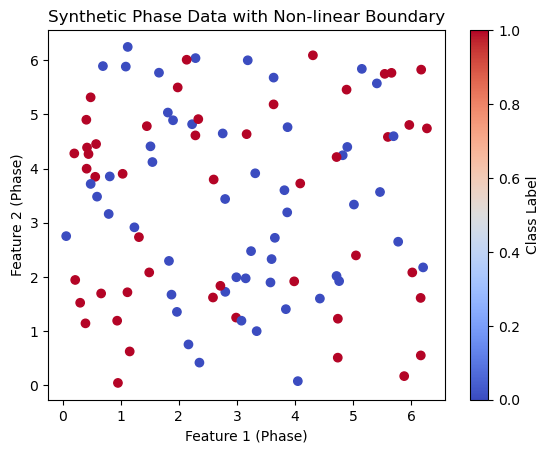

In [7]:
# Plot the sample of synthetic data
import matplotlib.pyplot as plt
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.numpy(), cmap='coolwarm')
plt.xlabel('Feature 1 (Phase)')
plt.ylabel('Feature 2 (Phase)')
plt.title('Synthetic Phase Data with Non-linear Boundary')
plt.colorbar(label='Class Label')
plt.show()




## 2. Definining the Variational Phasor Circuit (VPC) Structure
Our VPC will consist of:
1. **Data Encoding**: Feature values are encoded as absolute phase shifts `S(phi)`.
2. **Variational Layers**: Trainable weights are passed into phase shifts, interleaved with `Mix` and `DFT` gates to create interference and thread correlations.


In [8]:
def create_vpc(x, weights):
    """
    Builds the PhasorCircuit based on data x and parameters `weights`.
    Weights should be an array of length 24 (12 for Layer 1, 12 for Layer 2).
    """
    pc = pf.PhasorCircuit(num_features, name="VPC_Classifier")
    
    # --- DATA ENCODING ---
    for i in range(num_features):
        pc.shift(i, x[i])
        
    # --- VARIATIONAL LAYER 1 ---
    for i in range(num_features):
        pc.shift(i, weights[i])
        
    # Introduce local interference
    for i in range(0, num_features-1, 2):
        pc.mix(i, i+1)
        
    # --- VARIATIONAL LAYER 2 ---
    for i in range(num_features):
        pc.shift(i, weights[i + 12])
        
    # Introduce global interference / "Entanglement"
    pc.dft()
    
    return pc

# Let's visualize an un-optimized circuit structure:
dummy_w = torch.zeros(24)
test_pc = create_vpc(X[0], dummy_w)
print("VPC Architecture Preview:")
pf.draw(test_pc, mode='text')

VPC Architecture Preview:
T0: ──[S(5.54)]───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────[S(0.00)]─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────[S(0.00)]─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────┤
                                                                                                                                                                                                                                                                              [MIX]                                                                                                                                                                           │    
T1: ─────────────[S(5.75)]───────────────────────────────────────────

## 3. Loss Function
To train our weights, we must measure the circuit. Since Phase runs from $[-\pi, \pi]$, we will measure the angle of Thread 0, map it to a probability $[0, 1]$ using a sine envelope, and calculate Mean Squared Error.


In [9]:
engine = AnalyticEngine()

def vpc_predict(x, weights):
    pc = create_vpc(x, weights)
    res = engine.run(pc)
    
    # Read the phase of Thread 0
    phase_0 = res['phases'][0]
    
    # Map phase [-pi, pi] to probability [0, 1] using (sin(theta) + 1) / 2
    probability = (torch.sin(phase_0) + 1.0) / 2.0
    return probability
    
def calculate_loss(weights):
    predictions = torch.stack([vpc_predict(x, weights) for x in X])
    
    # Mean Squared Error
    mse = torch.mean((predictions - y)**2)
    return mse

# Initial loss with random weights
initial_weights = torch.empty(24).uniform_(-math.pi, math.pi)
initial_weights.requires_grad_(True)
initial_loss = calculate_loss(initial_weights)
print(f"Initial Random MSE Loss: {initial_loss.item():.4f}")

Initial Random MSE Loss: 0.2726


## 4. Optimization (Training)
We use `scipy.optimize.minimize` (COBYLA) to train our 24 physical parameters to minimize the MSE.


In [10]:
print("Starting Adam Optimization Native to Unit Circle...")

optimizer = optim.Adam([initial_weights], lr=0.1)

for epoch in range(100):
    optimizer.zero_grad()
    loss = calculate_loss(initial_weights)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/100 | Loss: {loss.item():.4f}")

optimal_weights = initial_weights.detach()
final_loss = loss.item()

print(f"Optimization Complete!")
print(f"Final Trained MSE Loss: {final_loss:.4f}")

Starting Adam Optimization Native to Unit Circle...
Epoch 20/100 | Loss: 0.0933
Epoch 40/100 | Loss: 0.0470
Epoch 60/100 | Loss: 0.0416
Epoch 80/100 | Loss: 0.0387
Epoch 100/100 | Loss: 0.0404
Optimization Complete!
Final Trained MSE Loss: 0.0404


## 5. Evaluation
Let's see our VPC's classification accuracy using the optimal parameters.


In [11]:
final_probs = torch.stack([vpc_predict(x, optimal_weights) for x in X])
binary_predictions = (final_probs > 0.5).float()

accuracy = torch.mean((binary_predictions == y).float()) * 100
print(f"Final Classification Accuracy: {accuracy.item():.2f}%")

Final Classification Accuracy: 98.00%
